In [1]:
# ============================================================
# 1. DATA LOADING AND EXPLORATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

df = pd.read_csv("Apple_Stock_Prices_(1981 to 2023).csv")

print(df.head())

print("\nDimensions")
print(df.shape)

print("\nTypes")
print(df.dtypes)

print("\nValeurs nulles")
print(df.isnull().sum())

         Date      Open      High       Low     Close  Adj Close    Volume
0  02/01/1981  0.154018  0.155134  0.154018  0.154018   0.119849  21660800
1  05/01/1981  0.151228  0.151228  0.150670  0.150670   0.117244  35728000
2  06/01/1981  0.144531  0.144531  0.143973  0.143973   0.112032  45158400
3  07/01/1981  0.138393  0.138393  0.137835  0.137835   0.107256  55686400
4  08/01/1981  0.135603  0.135603  0.135045  0.135045   0.105085  39827200

Dimensions
(10608, 7)

Types
Date             str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Valeurs nulles
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [2]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

df = df.sort_values("Date")

df.set_index("Date", inplace=True)

print(df.head())

                Open      High       Low     Close  Adj Close    Volume
Date                                                                   
1981-01-02  0.154018  0.155134  0.154018  0.154018   0.119849  21660800
1981-01-05  0.151228  0.151228  0.150670  0.150670   0.117244  35728000
1981-01-06  0.144531  0.144531  0.143973  0.143973   0.112032  45158400
1981-01-07  0.138393  0.138393  0.137835  0.137835   0.107256  55686400
1981-01-08  0.135603  0.135603  0.135045  0.135045   0.105085  39827200


In [3]:
print("Première date :", df.index.min())
print("Dernière date :", df.index.max())

print("Nombre de jours :", len(df))

Première date : 1981-01-02 00:00:00
Dernière date : 2023-01-27 00:00:00
Nombre de jours : 10608


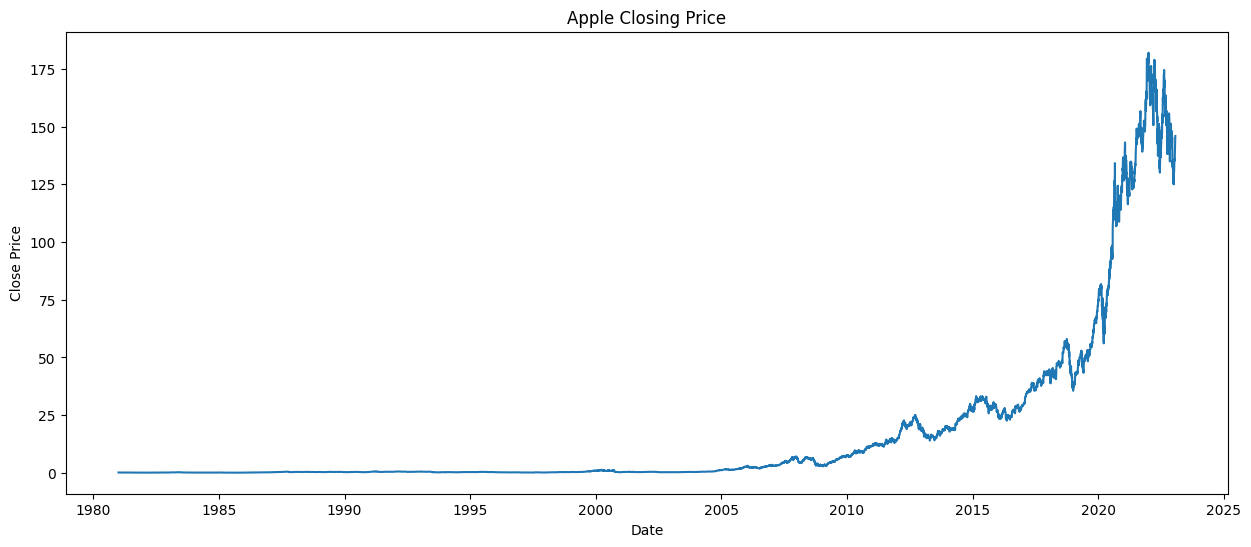

In [4]:
# ============================================================
# CLOSE PRICE
# ============================================================

plt.figure(figsize=(15,6))

plt.plot(
    df.index,
    df["Close"]
)

plt.title("Apple Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

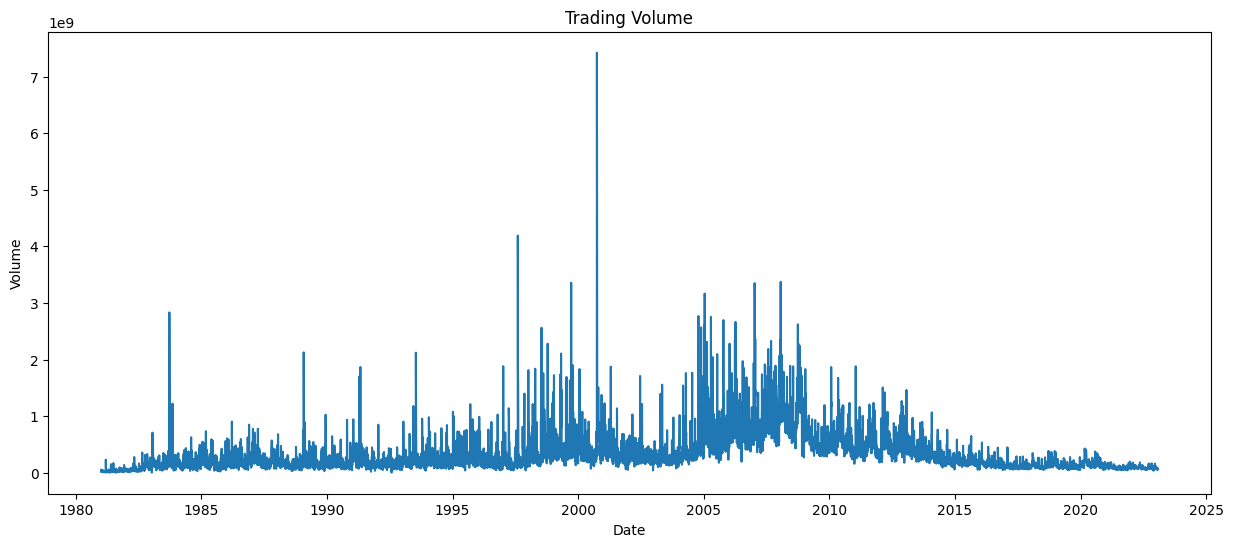

In [5]:
# ============================================================
# TRADING VOLUME
# ============================================================

plt.figure(figsize=(15,6))

plt.plot(
    df.index,
    df["Volume"]
)

plt.title("Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

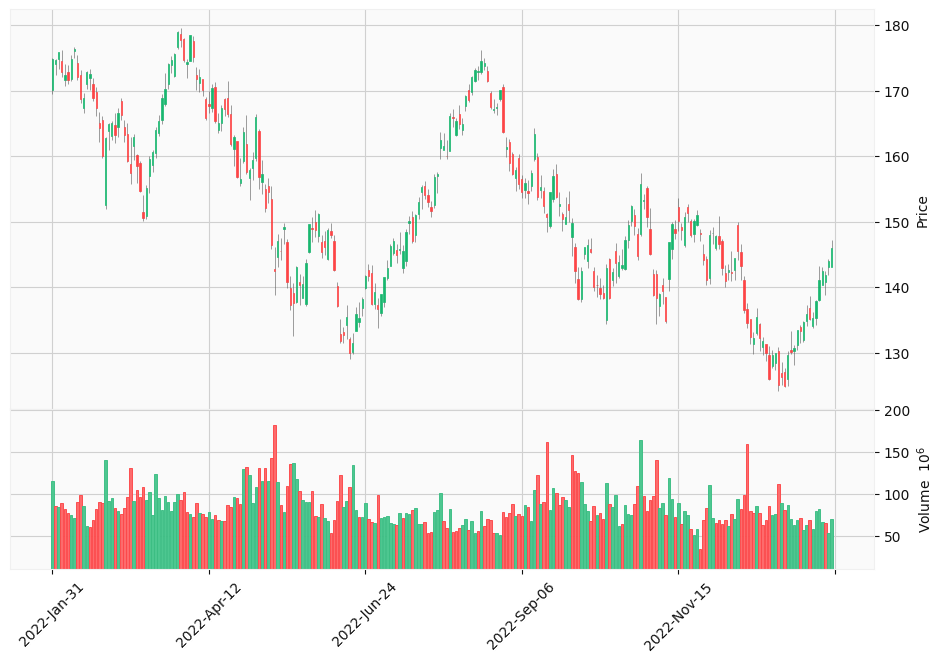

In [6]:
import mplfinance as mpf

mpf.plot(
    df.tail(250),
    type='candle',
    volume=True,
    style='yahoo',
    figsize=(12,8)
)

In [7]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

print(df.describe())

print("\nMédiane")
print(df.median(numeric_only=True))

               Open          High           Low         Close     Adj Close  \
count  10608.000000  10608.000000  10608.000000  10608.000000  10608.000000   
mean      16.689173     16.879955     16.500822     16.697362     16.027345   
std       35.450519     35.882848     35.031289     35.473912     35.154878   
min        0.049665      0.049665      0.049107      0.049107      0.038213   
25%        0.287946      0.296875      0.282355      0.288923      0.238909   
50%        0.488839      0.495536      0.480446      0.487701      0.404851   
75%       16.320893     16.418483     16.151249     16.269554     14.073167   
max      182.630005    182.940002    179.119995    182.009995    180.959747   

             Volume  
count  1.060800e+04  
mean   3.275098e+08  
std    3.378203e+08  
min    0.000000e+00  
25%    1.213044e+08  
50%    2.145976e+08  
75%    4.066804e+08  
max    7.421641e+09  

Médiane
Open         4.888390e-01
High         4.955360e-01
Low          4.804465e-01
Clo

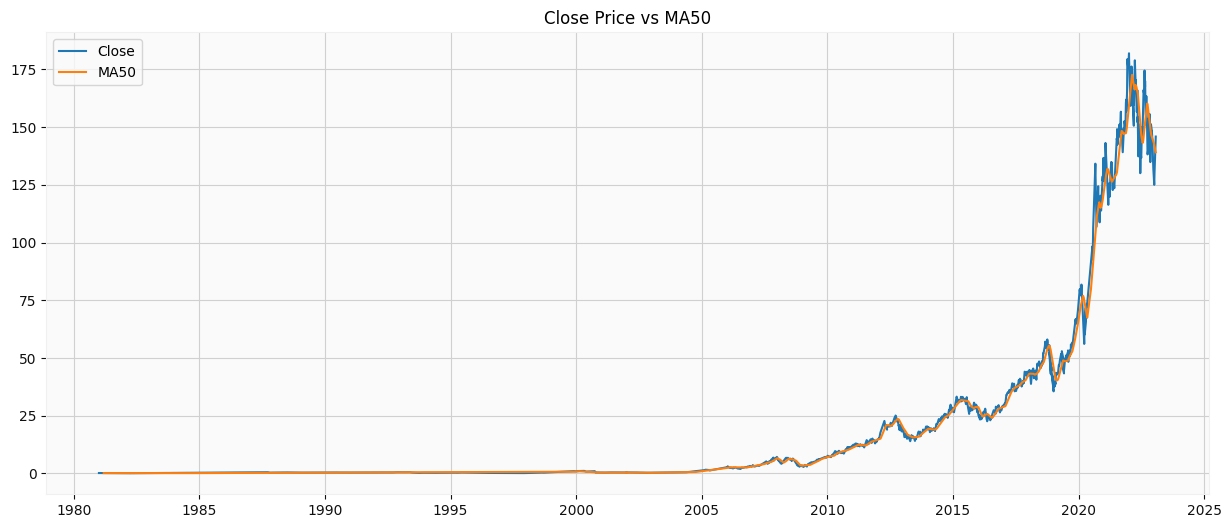

In [8]:
df["MA50"] = (
    df["Close"]
    .rolling(50)
    .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    df.index,
    df["Close"],
    label="Close"
)

plt.plot(
    df.index,
    df["MA50"],
    label="MA50"
)

plt.legend()

plt.title("Close Price vs MA50")

plt.show()

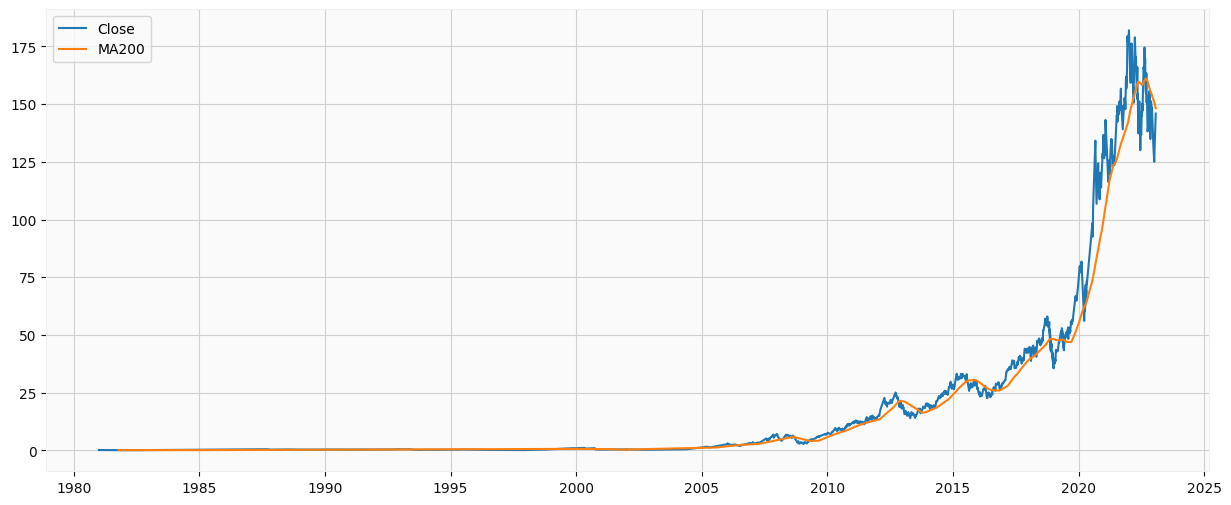

In [9]:
df["MA200"] = (
    df["Close"]
    .rolling(200)
    .mean()
)

plt.figure(figsize=(15,6))

plt.plot(df["Close"], label="Close")
plt.plot(df["MA200"], label="MA200")

plt.legend()

plt.show()

In [10]:
close_2022 = df[df.index.year == 2022]["Close"]
close_2023 = df[df.index.year == 2023]["Close"]

t_stat, p_value = stats.ttest_ind(
    close_2022,
    close_2023
)

print("T statistic :", t_stat)
print("P-value :", p_value)

T statistic : 6.4128167393735716
P-value : 6.456957567365969e-10


In [11]:
if p_value < 0.05:
    print("Différence significative")
else:
    print("Pas de différence significative")

Différence significative


In [12]:
# ============================================================
# DAILY RETURNS
# ============================================================

df["Return"] = (
    df["Close"]
    .pct_change()
)

df["Return"].dropna()

Date
1981-01-05   -0.021738
1981-01-06   -0.044448
1981-01-07   -0.042633
1981-01-08   -0.020242
1981-01-09    0.053715
                ...   
2023-01-23    0.023500
2023-01-24    0.010063
2023-01-25   -0.004701
2023-01-26    0.014803
2023-01-27    0.013684
Name: Return, Length: 10607, dtype: float64

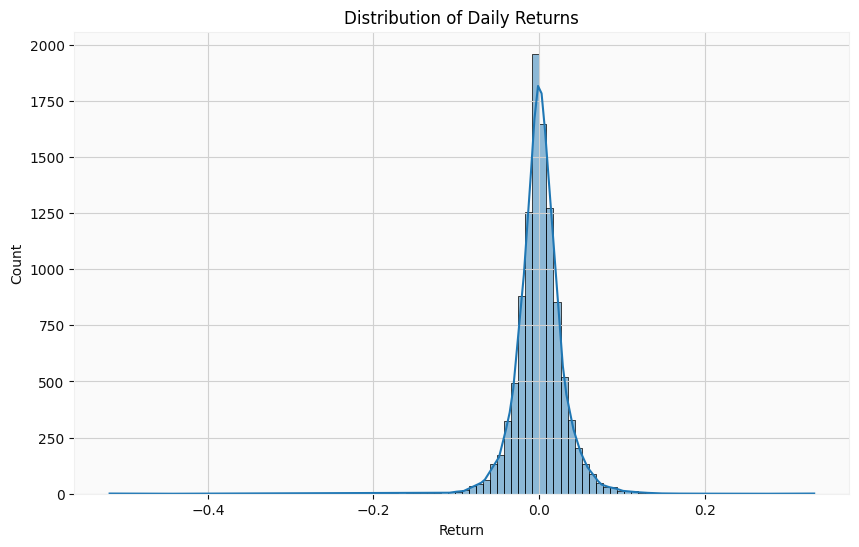

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

In [14]:
# ============================================================
# MOVING AVERAGE USING CONVOLVE
# ============================================================

window = 50

moving_average = np.convolve(
    df["Close"],
    np.ones(window)/window,
    mode="valid"
)

print(moving_average[:10])

[0.12583702 0.1248214  0.12397318 0.12339282 0.1229129  0.1225111
 0.12205352 0.1216071  0.12121646 0.12077002]


In [15]:
df["MA20"] = (
    df["Close"]
    .rolling(20)
    .mean()
)

df["MA100"] = (
    df["Close"]
    .rolling(100)
    .mean()
)

corr = np.corrcoef(
    df["MA20"].dropna()[-500:],
    df["Volume"].dropna()[-500:]
)

print(corr)

[[1.         0.08143156]
 [0.08143156 1.        ]]


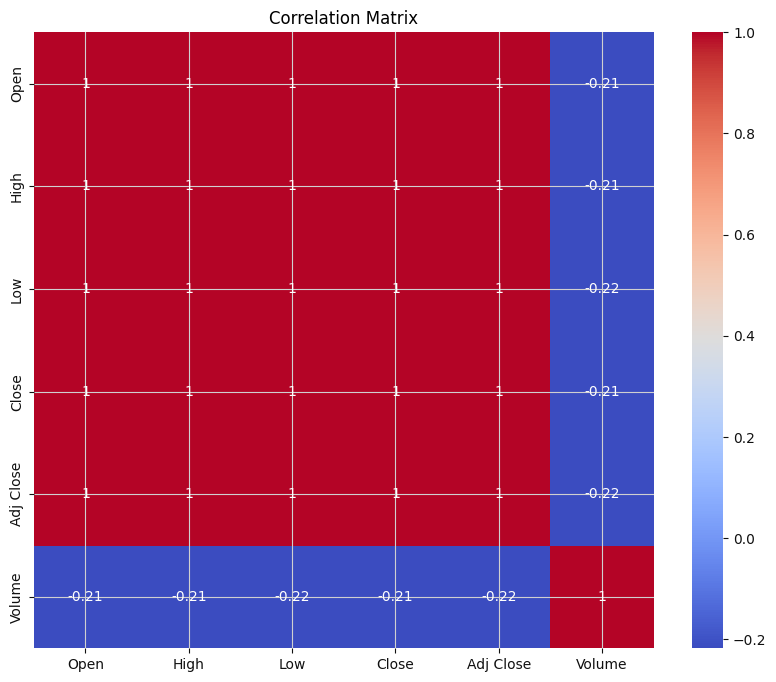

In [16]:
corr_matrix = df[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "Adj Close",
        "Volume"
    ]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()